# Plots EKE and energy transfers terms
## based on mean KE and EDDY files

In [1]:

# ----------------------------
# Standard library imports
# ----------------------------
import os
import sys


# ----------------------------
# Project-specific modules
# (add your ROMS Python modules directory to sys.path)
# ----------------------------
ROMS_MODULES_DIR = "/net/libra/local/tmp/1/gula/Python_for_roms/Python_Modules_p3/"
if ROMS_MODULES_DIR not in sys.path:
    sys.path.append(ROMS_MODULES_DIR)

from Modules import *        # noqa: F403  (wildcard import is legacy but kept)
from Modules_gula import *   # noqa: F403


# ----------------------------
# Scientific / plotting stack
# ----------------------------
import numpy.ma as ma
import cartopy
import cartopy.crs as ccrs

from scipy.integrate import trapz


# ----------------------------
# Jupyter / Matplotlib settings
# ----------------------------
# In notebooks, render figures in the output cell
%matplotlib inline


no amg module


In [3]:
region = 'all'


cases = {'gigatl6_1h_UP3': '6 km, GLS, CFSR1h',\
         'gigatl6_1h_tides': '6 km, GLS, CFSR1h, tides',\
         'gigatl6_1h_UP3_KPP_soda342_mon': '6 km, KPP, CFSR1h, soda342mon',\
         'gigatl3_1h': '3 km, GLS, CFSR1h',\
         'gigatl3_1h_tides': '3 km, GLS, CFSR1h, tides',\
         'gigatl3_1h_UP3_KPP_soda342_mon': '6 km, KPP, CFSR1h, soda342mon',\
         'gigatl3_1h_UP3_KPP_tides_soda342_mon': '6 km, KPP, CFSR1h, soda342mon, tides',\
         'aviso': 'AVISO',\
         'noaa': 'Drifters from NOAA',\
         }


## Functions to load datasets and compute terms

In [4]:
def get_hrs(simul, umean, vmean, uumean, vvmean, uvmean):
    """
    Compute HRS and eddy flux terms from mean and second-moment fields.
    All inputs are expected on rho grid unless stated otherwise.
    """
    uvp = uvmean - umean * vmean
    uup = uumean - umean**2
    vvp = vvmean - vmean**2

    # Gradients of mean flow
    dxv = tools.u2rho(tools.diffx(vmean, simul.pm))
    dyu = tools.v2rho(tools.diffy(umean, simul.pn))
    dxu = tools.u2rho(tools.diffx(umean, simul.pm))
    dyv = tools.v2rho(tools.diffy(vmean, simul.pn))

    # HRS
    hrs = -(uvp * dxv + uvp * dyu + uup * dxu + vvp * dyv)

    # Gradients of eddy moments
    dxuv = tools.u2rho(tools.diffx(uvp, simul.pm))
    dxuu = tools.u2rho(tools.diffx(uup, simul.pm))
    dyuv = tools.v2rho(tools.diffy(uvp, simul.pn))
    dyvv = tools.v2rho(tools.diffy(vvp, simul.pn))

    # Eddy flux term
    eddyflx = -(vmean * dxuv + umean * dxuu + umean * dyuv + vmean * dyvv)

    return hrs, eddyflx


def _apply_mask(simul):
    """Convert 0 mask to NaN (in-place) and return it for convenience."""
    simul.mask = simul.mask.astype(float)
    simul.mask[simul.mask == 0] = np.nan
    return simul.mask


def get_var(simul, simul_eddy):
    """Surface HRS + EKE from (mean) + (eddy second moments) simulations."""
    mask = _apply_mask(simul)

    umean = tools.u2rho(var("u", simul, depths=[0]).data) * mask
    vmean = tools.v2rho(var("v", simul, depths=[0]).data) * mask

    uumean = var("uu", simul_eddy, depths=[0]).data
    vvmean = var("vv", simul_eddy, depths=[0]).data
    uvmean = var("uv", simul_eddy, depths=[0]).data

    # Make sure moments are on rho grid
    if uumean.shape != vvmean.shape:
        uumean = tools.u2rho(uumean)
        vvmean = tools.v2rho(vvmean)

    hrs, eddyflx = get_hrs(simul, umean, vmean, uumean, vvmean, uvmean)

    eke = (0.5 * (uumean + vvmean) - 0.5 * (umean**2 + vmean**2)) * mask
    return umean, vmean, eke, hrs, eddyflx


def get_var_uvvar(simul, simul_uvvar):
    """Surface EKE (and MKE) from mean + uvvar dataset (no HRS/eddyflx here)."""
    mask = _apply_mask(simul)

    umean = tools.u2rho(var("u", simul, depths=[0]).data) * mask
    vmean = tools.v2rho(var("v", simul, depths=[0]).data) * mask

    uumean = tools.u2rho(var("u", simul_uvvar, depths=[0]).data)
    vvmean = tools.v2rho(var("v", simul_uvvar, depths=[0]).data)

    mke = 0.5 * (umean**2 + vmean**2)
    eke = (0.5 * (uumean + vvmean) - mke) * mask
    return umean, vmean, eke, mke


def coarsen(field2d, factor):
    """Coarsen a 2D array by averaging over factor x factor blocks (pads with zeros)."""
    shape = np.array(field2d.shape)
    new_shape = factor * np.ceil(shape / factor).astype(int)

    print("\noriginal shape is", tuple(shape))
    print("shape for padded array is", tuple(new_shape))

    if not np.array_equal(new_shape, shape):
        padded = np.zeros(new_shape, dtype=field2d.dtype)
        padded[: shape[0], : shape[1]] = field2d
    else:
        padded = field2d

    tmp = padded.reshape(
        (padded.shape[0] // factor, factor, padded.shape[1] // factor, factor)
    )
    out = np.mean(tmp, axis=(1, 3))

    print("coarsened shape is", out.shape)
    return out


def _read_uv_moments(meanfile_uv, simul, *, time_index=0, depth_index=None):
    """
    Read u, v, uu, vv, uv from a netCDF file and put them in simul.Forder order.
    depth_index=None -> assume [time, y, x]
    depth_index=int  -> assume [time, z, y, x] and use that z index
    """
    with Dataset(meanfile_uv, "r") as nc:
        if depth_index is None:
            sl = (time_index, slice(None), slice(None))
        else:
            sl = (time_index, depth_index, slice(None), slice(None))

        umean = simul.Forder(nc.variables["u"][sl])
        vmean = simul.Forder(nc.variables["v"][sl])
        uumean = simul.Forder(nc.variables["uu"][sl])
        vvmean = simul.Forder(nc.variables["vv"][sl])
        uvmean = simul.Forder(nc.variables["uv"][sl])

    return umean, vmean, uumean, vvmean, uvmean


def get_data(case, year, days=False, meanonly=False):
    year = str(year)
    # --------------------------
    # GIGATL*
    # --------------------------
    if "gigatl6" in case or "gigatl3" in case:
        simul = load(f"{case}_mean{year}", time=0, output=False)

        if meanonly:
            mask = _apply_mask(simul)
            umean = tools.u2rho(var("u", simul, depths=[0]).data) * mask
            vmean = tools.v2rho(var("v", simul, depths=[0]).data) * mask
            return simul.x, simul.y, umean, vmean

        if not days:
            simul_eddy = load(f"{case}_eddy_mean{year}", time=0, output=False)
            print("\n", simul.ncfile, "\n", simul_eddy.ncfile, "\n")
            umean, vmean, eke, hrs, eddyflx = get_var(simul, simul_eddy)
        else:
            simul_uvvar = load(f"{case}_uvvar_mean{year}", time=0, output=False)
            print("\nopen 5d var")
            print(simul.ncfile)
            print(simul_uvvar.ncfile)
            print()

            # NOTE: your original code called get_var_uvvar but still unpacked hrs/eddyflx.
            # Here we keep behavior explicit:
            umean, vmean, eke, mke = get_var_uvvar(simul, simul_uvvar)
            hrs = None
            eddyflx = None

        return simul.x, simul.y, umean, vmean, eke, hrs, eddyflx

    # --------------------------
    # AVISO
    # --------------------------
    if "aviso" in case:
        # year handling
        year_aviso = year if len(year) == 4 else "2009-2011"

        avisoname = (
            folder_obs
            + "AVISO_quart/UV/means/dt_global_allsat_madt_uv_"
            + year_aviso
            + ".mean.nc"
        )
        with Dataset(avisoname) as nc:
            umean_aviso = nc.variables["u"][0, :, :].T
            vmean_aviso = nc.variables["v"][0, :, :].T

        avisoname = (
            folder_obs
            + "AVISO_quart/UV/means/dt_global_allsat_madt_uv_"
            + year_aviso
            + ".var.mean.nc"
        )
        with Dataset(avisoname) as nc:
            uumean = nc.variables["u"][0, :, :].T
            vvmean = nc.variables["v"][0, :, :].T

        mke_aviso = 0.5 * (umean_aviso**2 + vmean_aviso**2)
        eke_aviso = 0.5 * (uumean + vvmean) - mke_aviso

        return lon_aviso, lat_aviso, umean_aviso, vmean_aviso, eke_aviso, hrs_aviso, eddyflx_aviso

    raise ValueError(f"Case not recognized: {case}")


## Plotting functions

In [5]:

# ----------------------------
# Plot style
# ----------------------------
FONTSIZE_SMALL = 5
FONTSIZE = 9
FONTSIZE_LARGE = 12
FONTSIZE_XL = 22

plt.rc("font", size=FONTSIZE)


def my_panel(
    ax,
    field,
    *,
    simul=None,
    x=None,
    y=None,
    levels=np.arange(-1.0, 1.01, 0.01),
    extent=(-100.0, 0.0, 20.0, 70.0),
    cmap="blu_red",
    varlabel=r"$\zeta$",
):
    """Single map panel with pcolormesh + colorbar + label."""

    # Map cosmetics
    ax.set_extent(extent)
    ax.coastlines(resolution="10m")
    ax.stock_img()

    gl = ax.gridlines(draw_labels=True)
    gl.bottom_labels = False
    gl.right_labels = False

    # Colormap
    my_cmap = plot.ncview_colormap(cmap)

    # Optional masking / coords from `simul`
    if simul is not None:
        simul.mask = simul.mask.astype(float)
        simul.mask[simul.mask == 0] = np.nan
        field = field * simul.mask
        x, y = simul.x, simul.y

    if x is None or y is None:
        raise ValueError("Provide x and y (or pass simul with simul.x/simul.y).")

    mesh = ax.pcolormesh(
        x,
        y,
        ma.masked_invalid(field),
        vmin=np.min(levels),
        vmax=np.max(levels),
        cmap=my_cmap,
        transform=ccrs.PlateCarree(),
    )

    plt.colorbar(mesh, ax=ax, shrink=0.25)
    ax.text(
        0.04,
        0.9,
        varlabel,
        fontsize=FONTSIZE,
        ha="left",
        transform=ax.transAxes,
    )


def my_plot(
    x,
    y,
    umean,
    vmean,
    eke,
    hrs,
    eddyflx,
    year,
    *,
    region=region,
    addtitle="",
):
    year = str(year)

    # Defaults
    central_lon, central_lat = -35.16421250966554, 7.720167269605723

    # Region presets
    if region == "NA":
        extent = (-100.0, 0.0, -10.0, 70.0)
        fig = plt.figure(figsize=(10, 5), facecolor="white", edgecolor="black")
    elif region == "all":
        extent = (-100.0, 20.0, -55.0, 70.0)
        fig = plt.figure(figsize=(25, 20), facecolor="white", edgecolor="black")
    elif region == "GS":
        extent = (-82.0, -40.0, 25.0, 45.0)
        fig = plt.figure(figsize=(18, 10), facecolor="white", edgecolor="black")
    elif region == "SP":
        extent = (-82.0, -30.0, 20.0, 70.0)
        fig = plt.figure(figsize=(10, 7), facecolor="white", edgecolor="black")
        central_lon, central_lat = -60, 40
    elif region == "MA":
        extent = (-70.0, -30.0, -55.0, -20.0)
        fig = plt.figure(figsize=(10, 7), facecolor="white", edgecolor="black")
        central_lon, central_lat = -60, -40
    else:
        raise ValueError(f"Unknown region: {region}")

    # Levels/labels
    levels_hrs = np.arange(-1.0, 1.01, 0.01) * 0.5e-6
    levels_ke = np.arange(0, 3000, 100)
    varlabel_ke = r"EKE [cm$^2$/s$^2$]"

    # Title
    try:
        title = f"{cases[case]} for {year}"
    except Exception:
        title = f"{case} for {year}"

    # Subplots
    proj = ccrs.Orthographic(central_lon, central_lat)

    ax1 = fig.add_subplot(221, facecolor="Gainsboro", projection=proj)
    ax1.set_title(title, fontsize=FONTSIZE)
    my_panel(
        ax1,
        eke * 1e4,
        x=x,
        y=y,
        extent=extent,
        levels=levels_ke,
        cmap="jaisnd",
        varlabel=varlabel_ke,
    )

    ax2 = fig.add_subplot(222, facecolor="Gainsboro", projection=proj)
    my_panel(
        ax2,
        hrs,
        x=x,
        y=y,
        extent=extent,
        levels=levels_hrs,
        cmap="blu_red",
        varlabel="MEC",
    )

    ax3 = fig.add_subplot(223, facecolor="Gainsboro", projection=proj)
    my_panel(
        ax3,
        eddyflx,
        x=x,
        y=y,
        extent=extent,
        levels=levels_hrs,
        cmap="blu_red",
        varlabel="EDDYFLX",
    )

    ax4 = fig.add_subplot(224, facecolor="Gainsboro", projection=proj)
    my_panel(
        ax4,
        eddyflx + hrs,
        x=x,
        y=y,
        extent=extent,
        levels=levels_hrs,
        cmap="blu_red",
        varlabel="MEC+EDDYFLX",
    )

    plt.subplots_adjust(wspace=0.1, hspace=0.2)

    out = f"hrs_{case}_{region}_{year}{addtitle}_for_6km.png"
    plt.savefig(out, bbox_inches="tight", transparent=True, dpi=200)
    return out


# Example:
# my_plot(x, y, umean, vmean, eke, hrs, eddyflx, year=year, addtitle=title, region="SP")




 /data-gigatl/data/GIGATL3/GIGATL3_1h_UP3_KPP_soda342_mon//GIGATL3_5d_aver_2006.mean.nc 
 /data-gigatl/data/GIGATL3/GIGATL3_1h_UP3_KPP_soda342_mon//GIGATL3_5d_EDDY_2006.mean.nc 



'hrs_gigatl3_1h_UP3_KPP_soda342_mon_GS_2006_for_6km.png'

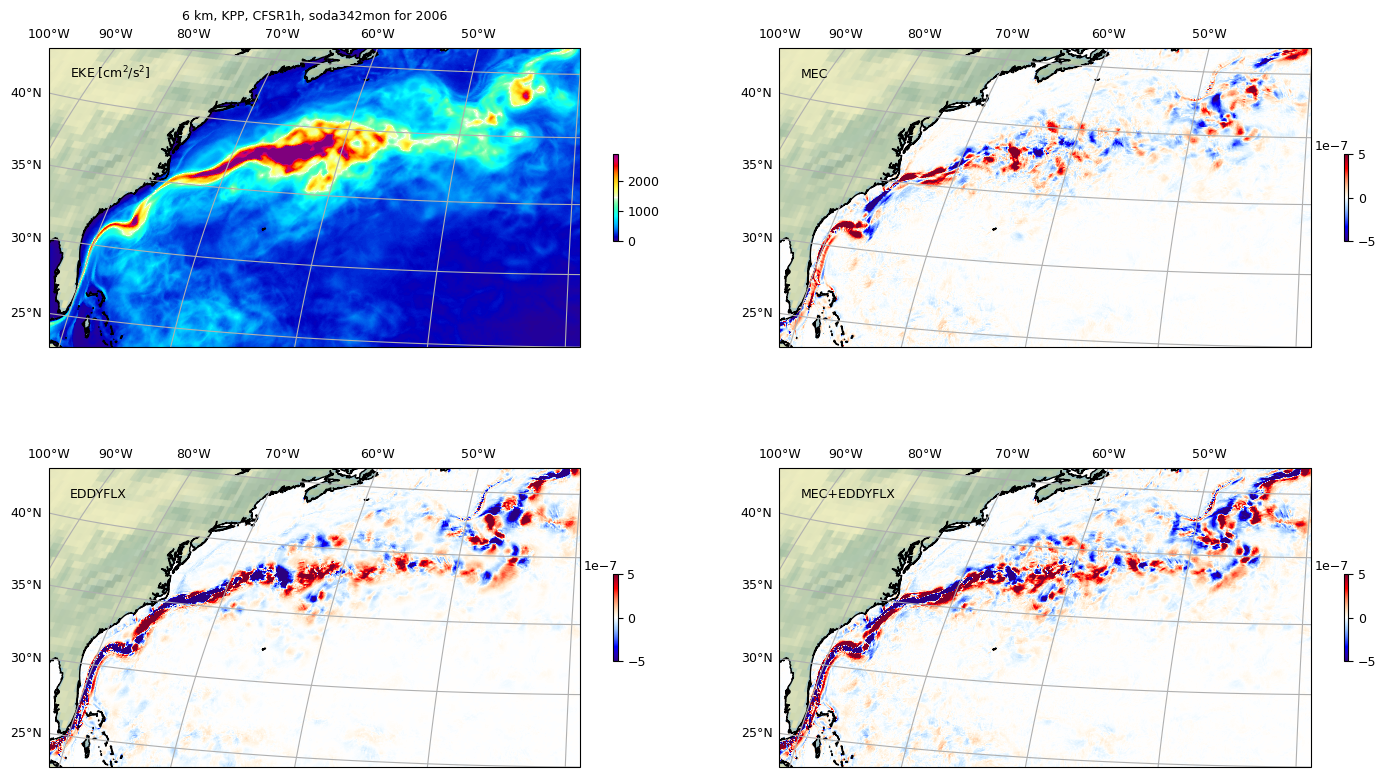

In [6]:
year='2006';   case='gigatl6_1h_UP3_KPP_soda342_mon'

year='2006';   case='gigatl3_1h_UP3_KPP_soda342_mon'
region = 'GS'; days = False

# Load data
x, y, umean, vmean, eke, hrs, eddyflx = get_data(case, year = year, days=days); title =''

# Plot
my_plot(x, y, umean, vmean, eke, hrs, eddyflx, year = year, addtitle=title, region = region)
